In [78]:
import pandas as pd
from sklearn.model_selection import train_test_split
from mixed_naive_bayes import MixedNB
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

## 1. Load in Data and Split Training and Testing Data

In [79]:
# Read in the cleaned CSV file
df = pd.read_csv('nb_project_data.csv')

# Separate independent and dependent variables
x = df.iloc[:, :-1]
y = df.loc[:, ['conversions']]

# Split the training and testing data with a ratio of 80:20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# Convert dependent variable to 1D array to work with sklearn
y_train = y_train.to_numpy().ravel()
y_test = y_test.to_numpy().ravel()

## 2. Mixed Naïve Bayes
This classifier uses multinoulli and Gaussian Naïve Bayes algorithms to handle both categorical and continuous data. Grid search is used since Naïve Bayes algorithms are quick to train.

In [80]:
# Perform hyperparameter tuning with grid search
var_smoothing = np.logspace(0, -9, num=100)
alphas = [0.01, 0.1, 1.0, 10]

# Initialize variables to track the best accuracy and best hyperparameters
best_score = 0
best_params= {'alpha': None, 'var_smoothing': None}

# Iterate over all the hyperparameters
for var_smoothing_val in var_smoothing:
    for alpha in alphas:
        # Create mixed Naïve Bayes classifier
        mixed_nb = MixedNB(categorical_features=[1,2,3,4], alpha=alpha, var_smoothing=var_smoothing_val)
        # Calculate cross validation score
        scores = cross_val_score(mixed_nb, x_train, y_train, cv=5)
        avg_score = np.mean(scores)
        # Update best score and best hyperparameters
        if avg_score > best_score:
            best_score = avg_score
            best_params['alpha'] = alpha
            best_params['var_smoothing'] = var_smoothing_val

Best Hyperparameters: 
alpha: 0.01, var_smoothing: 8.111308307896873e-06

Best Score: 0.9090250000000001

                   precision    recall  f1-score   support

Not Converted (0)       0.61      0.27      0.37      2063
    Converted (1)       0.92      0.98      0.95     17937

         accuracy                           0.91     20000
        macro avg       0.76      0.62      0.66     20000
     weighted avg       0.89      0.91      0.89     20000



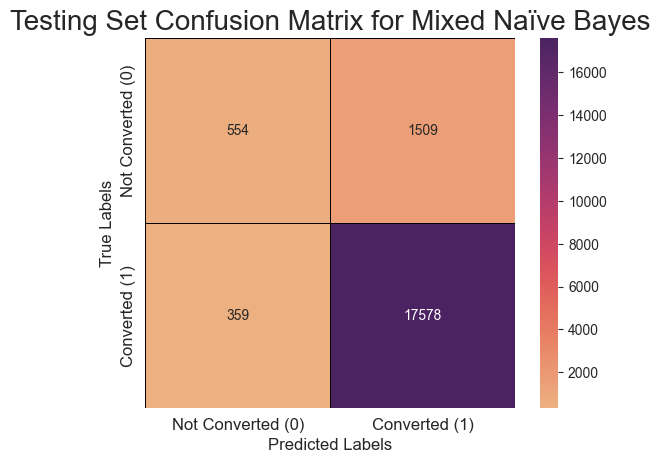

In [81]:
# Display best hyperparameters
print(f'Best Hyperparameters: \nalpha: {best_params['alpha']}, var_smoothing: {best_params['var_smoothing']}')
print(f'\nBest Score: {best_score}\n')

# Make predictions on test data
best_model = MixedNB(categorical_features=[1,2,3,4], alpha=best_params['alpha'], var_smoothing=best_params['var_smoothing'])
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)

# Display metrics
class_report = classification_report(y_test, y_pred, target_names=['Not Converted (0)', 'Converted (1)'], zero_division=0)
print(class_report)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
matrix = confusion_matrix(y_test, y_pred)
ax = plt.subplot()
sns.heatmap(matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True)
ax.set_title("Testing Set Confusion Matrix for Mixed Naïve Bayes", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=12)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=12)
plt.show()

The poor accuracy of the model on the `0` class reflects the imbalance in the dataset.

## 3. Oversample the data
Because `conversions` is imbalanced, with many more 1s than 0s, we use oversampling to address this class imbalance that can bias our models. We apply oversampling only the training data to avoid data leakage.

In [82]:
# Use random oversampling
oversample = RandomOverSampler(random_state=0)

# Apply oversampling to the data
x_over, y_over = oversample.fit_resample(x_train, y_train)

# Summarize the 'conversions' class distribution
distribution = dict(Counter(y_train))
over_distribution = dict(Counter(y_over))
print(f'Class Distribution Before Oversampling:\n1: {distribution[1]}, 0: {distribution[0]}')
print(f'\nClass Distribution After Oversampling:\n1: {over_distribution[1]}, 0: {over_distribution[0]}')


Class Distribution Before Oversampling:
1: 71855, 0: 8145

Class Distribution After Oversampling:
1: 71855, 0: 71855


## 4. Create a New Naïve Bayes Classifier with Oversampling


In [83]:
# Perform hyperparameter tuning with grid search
var_smoothing = np.logspace(0, -9, num=100)
alphas = [0.01, 0.1, 1.0, 10]

# Initialize variables to track the best accuracy and best hyperparameters
best_score = 0
best_params= {'alpha': None, 'var_smoothing': None}

# Iterate over all the hyperparameters
for var_smoothing_val in var_smoothing:
    for alpha in alphas:
        # Create mixed Naïve Bayes classifier
        mixed_nb = MixedNB(categorical_features=[1,2,3,4], alpha=alpha, var_smoothing=var_smoothing_val)
        # Calculate cross validation score
        scores = cross_val_score(mixed_nb, x_over, y_over, cv=5)
        avg_score = np.mean(scores)
        # Update best score and best hyperparameters
        if avg_score > best_score:
            best_score = avg_score
            best_params['alpha'] = alpha
            best_params['var_smoothing'] = var_smoothing_val

Best Hyperparameters: 
alpha: 0.01, var_smoothing: 1e-09

Best Score: 0.8556259132976132

                   precision    recall  f1-score   support

Not Converted (0)       0.39      0.94      0.55      2063
    Converted (1)       0.99      0.83      0.90     17937

         accuracy                           0.84     20000
        macro avg       0.69      0.88      0.72     20000
     weighted avg       0.93      0.84      0.87     20000



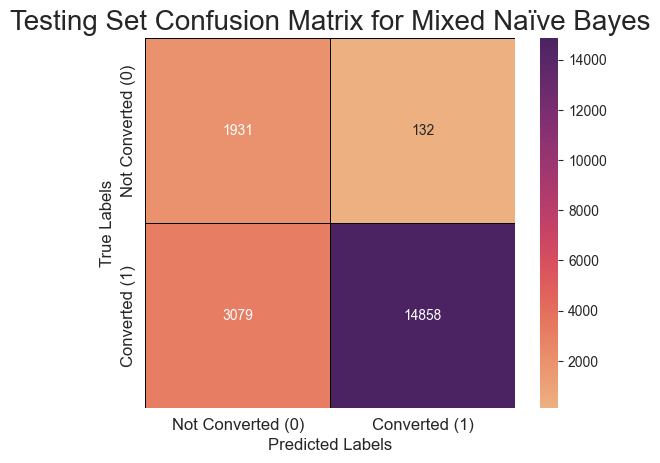

In [84]:
# Display best hyperparameters
print(f'Best Hyperparameters: \nalpha: {best_params['alpha']}, var_smoothing: {best_params['var_smoothing']}')
print(f'\nBest Score: {best_score}\n')

# Make predictions on test data
best_model = MixedNB(categorical_features=[1,2,3,4], alpha=best_params['alpha'], var_smoothing=best_params['var_smoothing'])
best_model.fit(x_over, y_over)
y_pred = best_model.predict(x_test)

# Display metrics
class_report = classification_report(y_test, y_pred, target_names=['Not Converted (0)', 'Converted (1)'], zero_division=0)
print(class_report)

# Create confusion matrix for the testing set
matrix_labels = ['Not Converted (0)', 'Converted (1)']
matrix = confusion_matrix(y_test, y_pred)
ax = plt.subplot()
sns.heatmap(matrix, annot=True, fmt="g", ax=ax, cmap="flare",
            linewidths=0.5, linecolor="black", square=True)
ax.set_title("Testing Set Confusion Matrix for Mixed Naïve Bayes", fontsize=20)
ax.set_xlabel("Predicted Labels", fontsize=12)
ax.set_ylabel("True Labels", fontsize=12)
ax.xaxis.set_ticklabels(matrix_labels, fontsize=12)
ax.yaxis.set_ticklabels(matrix_labels, fontsize=12)
plt.show()